### DataSet Link: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

**Goal:**

The objective of this project is to:
- Predict customers likely to churn
- Understand drivers of churn
- Design targeted retention strategies
- Maximize marketing ROI using uplift modeling

## 1. Loading Data:

In [9]:
import pandas as pd
df=pd.read_csv("/content/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Data Inspection:

In [10]:
df.shape

(1067371, 8)

In [11]:
df['Customer ID'].nunique()

5942

The dataset contains approximately 1 million records covering 5,942 unique customers, with detailed information on their purchases in retail.

## 3. Data Cleaning:

In [12]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [13]:
df['Customer ID']=df['Customer ID'].ffill()

Forward-filled missing ```Customer IDs```, as removing these huge number of customers will impact our data size and causes information loss.

In [14]:
new_df=df.dropna()
new_df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


Since the `Description` column has only **0.4% missing values**, missing value rows can be safely removed from the dataset.


In [15]:
# Shape of new dataset
new_df.shape

(1062989, 8)

In [16]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1062989 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1062989 non-null  object 
 1   StockCode    1062989 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1062989 non-null  int64  
 4   InvoiceDate  1062989 non-null  object 
 5   Price        1062989 non-null  float64
 6   Customer ID  1062989 non-null  float64
 7   Country      1062989 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 73.0+ MB


In [17]:
# Change datatype of InvoiceDate Column to datetime
new_df['InvoiceDate'] = pd.to_datetime(new_df['InvoiceDate'])

/tmp/ipykernel_619/3568127502.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['InvoiceDate'] = pd.to_datetime(new_df['InvoiceDate'])


In [18]:
new_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.062989e+06,1062989,1.062989e+06,1.062989e+06
mean,1.005103e+01,2011-01-03 07:38:22.446045184,4.668554e+00,1.531496e+04
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,1.234600e+04
25%,1.000000e+00,2010-07-11 10:28:00,1.250000e+00,1.389200e+04
50%,3.000000e+00,2010-12-07 15:31:00,2.100000e+00,1.524900e+04
75%,1.000000e+01,2011-07-22 15:02:00,4.150000e+00,1.681400e+04
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,1.828700e+04
std,1.699307e+02,NaN,1.238071e+02,1.714875e+03


- Negative Quantity → Returns product

- CustomerID → user identifier

- Negative Price → reverse transactions

## 4. Feature Engineering:

1. Monetary : Total money spent [sum(Quantity * Price)]
2. Frequency : Number of purchases / invoices
3. Recency : How many days since last purchase

In [19]:
# ---------------------------------------------
# Step 1: Create Total Price per transaction
# ---------------------------------------------
# TotalPrice = Quantity × Price for each record
new_df['TotalPrice'] = new_df['Quantity'] * new_df['Price']


# ---------------------------------------------
# Step 2: Define analysis reference date
# ---------------------------------------------
# This will be used to calculate Recency (last purchase gap)
analysis_date = new_df['InvoiceDate'].max()


# ---------------------------------------------
# Step 3: Create RFM Features
# ---------------------------------------------

rfm = new_df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                      # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

# Rename columns for clarity
rfm.columns = ['Customer ID', 'DaysSinceLastPurchase', 'TotalOrder', 'TotalSpent']


# ---------------------------------------------
# Step 4: Customer Behavior Features
# ---------------------------------------------
# These describe purchasing habits of customers

behavior = new_df.groupby('Customer ID').agg({
    'Quantity': ['sum', 'mean'],       # total items purchased & avg items per order
    'TotalPrice': ['mean'],            # average order value
    'StockCode': 'nunique',            # number of unique products bought
    'Country': lambda x: x.mode()[0]   # most frequent country of customer
})

# Rename column names
behavior.columns = [
    'TotalItems',
    'AvgItemsPerOrder',
    'AvgOrderValue',
    'UniqueProducts',
    'Country'
]

behavior = behavior.reset_index()


# ---------------------------------------------
# Step 5: Purchase Gap Feature (Time between orders)
# ---------------------------------------------
# This captures how frequently customer buys (in days)

# Get each invoice date per customer
orders = new_df.groupby(['Customer ID', 'Invoice']).agg({
    'InvoiceDate': 'max'
}).reset_index()

# Sort by customer and date to calculate time gaps
orders = orders.sort_values(['Customer ID', 'InvoiceDate'])

# Get previous purchase date for each customer
orders['prev_date'] = orders.groupby('Customer ID')['InvoiceDate'].shift(1)

# Calculate gap in days between consecutive purchases
orders['gap'] = (orders['InvoiceDate'] - orders['prev_date']).dt.days

# Average gap per customer
gap_feature = orders.groupby('Customer ID')['gap'].mean().reset_index()
gap_feature.rename(columns={'gap': 'AvgPurchaseGap'}, inplace=True)

# Replace NaN (customers with only 1 order) with 0
gap_feature['AvgPurchaseGap'] = gap_feature['AvgPurchaseGap'].fillna(0)

# ---------------------------------------------
# Step 6: Last Purchase Features
# ---------------------------------------------

# Get last invoice date per customer
last_invoice_date = new_df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_invoice_date.rename(columns={'InvoiceDate': 'LastInvoiceDate'}, inplace=True)

# Merge to identify rows belonging to last invoice
last_purchase = pd.merge(
    new_df,
    last_invoice_date,
    left_on=['Customer ID', 'InvoiceDate'],
    right_on=['Customer ID', 'LastInvoiceDate'],
    how='inner'
)

# Identify last invoice number per customer
last_invoice_number = last_purchase.groupby('Customer ID')['Invoice'].first().reset_index()

# Merge to keep only that invoice
last_purchase = pd.merge(
    last_purchase,
    last_invoice_number,
    on=['Customer ID', 'Invoice'],
    how='inner'
)

# Calculate total order value of last invoice
last_order_value = last_purchase.groupby('Customer ID')['TotalPrice'].sum().reset_index()
last_order_value.rename(columns={'TotalPrice': 'LastOrderValue'}, inplace=True)

# Get most frequent item code in last invoice
last_item_code = last_purchase.groupby('Customer ID')['StockCode'] \
                              .agg(lambda x: x.mode()[0]) \
                              .reset_index()

last_item_code.rename(columns={'StockCode': 'LastPurchasedItemCode'}, inplace=True)

# Merge both features
last_features = pd.merge(
    last_order_value,
    last_item_code,
    on='Customer ID',
    how='left'
)

# ---------------------------------------------
# Step 7: Merge All Features Together
# ---------------------------------------------
# Combine RFM + Behavior + Gap features + Last item features into one dataset

data = pd.merge(rfm, behavior, on='Customer ID', how='left')
data = pd.merge(data, gap_feature, on='Customer ID', how='left')
data = pd.merge(data, last_features, on='Customer ID', how='left')

# ---------------------------------------------
# Step 7: Final dataset preview
# ---------------------------------------------
data.sample(6)

/tmp/ipykernel_619/235566814.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['TotalPrice'] = new_df['Quantity'] * new_df['Price']


,Customer ID,DaysSinceLastPurchase,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,AvgPurchaseGap,LastOrderValue,LastPurchasedItemCode
4575,16921.0,60,3,446.67,299,3.147368,4.701789,78,United Kingdom,269.000000,169.79,20914
2195,14541.0,58,19,3036.59,2248,9.289256,12.547893,142,United Kingdom,35.333333,146.00,46000S
3451,15797.0,112,8,2841.63,1286,91.857143,202.973571,14,United Kingdom,81.000000,367.20,85104
5098,17444.0,147,5,4619.40,2493,7.600610,14.083537,317,United Kingdom,6.250000,550.94,POST
1304,13650.0,16,18,9621.28,3049,8.262873,26.073930,287,United Kingdom,38.823529,298.24,21669
5556,17902.0,546,1,216.40,526,21.916667,9.016667,24,United Kingdom,0.000000,216.40,16033


In [20]:
# Now, we create our target column: Churn

# If customer misses 1 cycle → maybe delay/busy
# If customer misses 2 cycles → likely churn

data['Churn'] = (data['DaysSinceLastPurchase'] > 2 * data['AvgPurchaseGap']).astype(int)


So, till this we have created new data using pre-existing data.

Before going in ML part, lets first understand the correlation of the columns.

## 5. Data Visualization:

In [21]:
df.groupby('Customer ID')['Invoice'].count().sort_values(ascending=False)

,Invoice
Customer ID,
17841.0,14787
14911.0,14414
12748.0,9421
14606.0,8973
14156.0,6284
...,...
14033.0,1
16663.0,1
15657.0,1


CustomerID ```17841.0``` have maximum buying history.

In [22]:
!pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00


In [23]:
from ydata_profiling import ProfileReport

# Generate the report
profile = ProfileReport(data, title="My Data Report", explorative=True)

# Show it in Jupyter Notebook (if you're using one)
profile.to_notebook_iframe()


Output hidden; open in https://colab.research.google.com to view.

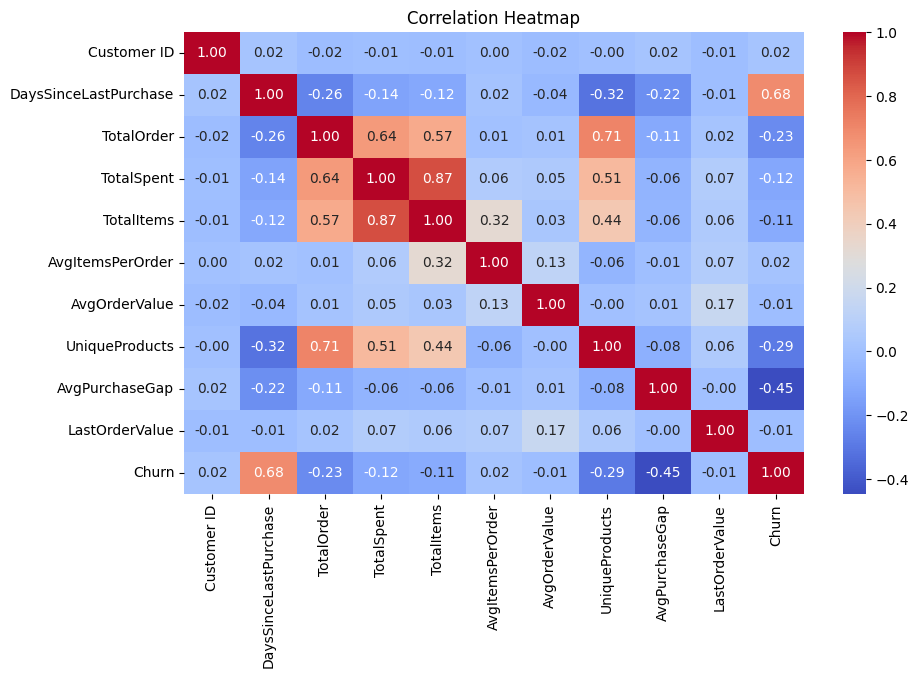

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = data.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()


**Insights:**

🔵 Strong Positive Correlations:
1. TotalSpent ↔ TotalItems = 0.87 means Customers who buy more items spend more money.
2. TotalOrder ↔ UniqueProducts = 0.71 means Customers who purchase more frequently explore more unique products. These are high value customers.

🔴 Negative Correlations:
1. DaysSinceLAstPurchase ↔ TotalItems = -0.26 means

    **Case 1:** Good Customer

        - Recency = LOW (they bought recently)

        - Frequency = HIGH (they buy often)

      These are loyal and active customers

    **Case 2:** Risk Customer

       - Recency = HIGH (they haven’t bought for long time)

       - Frequency = LOW (they rarely buy)

      These are inactive / churn-risk customers

2. AvgPurchaseGap ↔ TotalOrder = -0.11 means more frequent customers have smaller gaps between purchases.



---


**Features	Correlation**
- TotalSpent & TotalItems =	0.87
- TotalItems & UniqueProducts = 0.71

This means:

❗ They are giving similar information

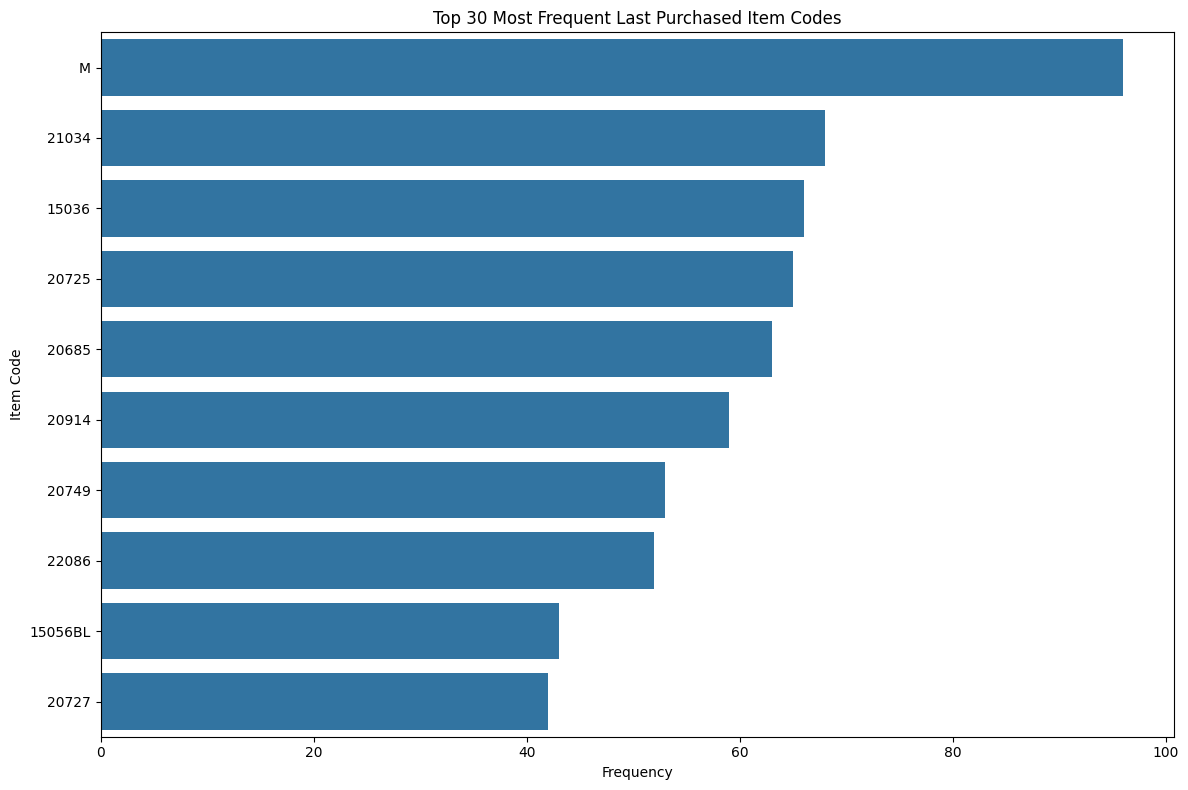

In [25]:
top_30_items = data['LastPurchasedItemCode'].value_counts().head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_30_items.values,
    y=top_30_items.index
)

plt.title("Top 30 Most Frequent Last Purchased Item Codes")
plt.xlabel("Frequency")
plt.ylabel("Item Code")

plt.tight_layout()
plt.show()

This shows that ItemCode 'M' is the most last purchased item of customers.

In [26]:
item_freq = data['LastPurchasedItemCode'].value_counts()
rare_items = item_freq[item_freq < 10].index

data['ItemType'] = data['LastPurchasedItemCode'].apply(
    lambda x: 'Rare' if x in rare_items else 'Frequent'
)
data.groupby('ItemType')['Churn'].mean()

,Churn
ItemType,
Frequent,0.486715
Rare,0.545590


Customers whose last purchase is a rare item are more likely to churn.

In [27]:
from scipy.stats import ttest_ind

rare = data[data['ItemType']=='Rare']['Churn']
freq = data[data['ItemType']=='Frequent']['Churn']

ttest_ind(rare, freq)

TtestResult(statistic=np.float64(4.512752202111937), pvalue=np.float64(6.522553054184389e-06), df=np.float64(5940.0))

p-value = 0.0000065 which is much smaller than 0.05. The difference in churn rate between Rare and Frequent item buyers is statistically significant.

In simple terms: The higher churn rate among rare-item buyers is NOT due to random chance.

Customers whose last purchase was a rare product exhibit significantly higher churn probability, suggesting exploratory or low-loyalty behavior.

In [28]:
data.sample(6)

,Customer ID,DaysSinceLastPurchase,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,AvgPurchaseGap,LastOrderValue,LastPurchasedItemCode,Churn,ItemType
493,12839.0,2,34,-30273.45,6847,11.565878,-51.137584,160,United Kingdom,21.727273,752.39,20713,0,Frequent
2007,14353.0,214,3,376.50,344,13.760000,15.060000,18,United Kingdom,108.000000,90.60,22653,0,Rare
1143,13489.0,104,4,449.52,560,40.000000,32.108571,11,United Kingdom,62.666667,162.48,23144,0,Rare
2601,14947.0,71,6,1049.79,416,7.703704,19.440556,47,United Kingdom,110.000000,112.32,22969,0,Rare
952,13298.0,0,1,360.00,96,48.000000,180.000000,2,United Kingdom,0.000000,360.00,21479,0,Frequent
1168,13514.0,73,4,815.90,288,13.714286,38.852381,15,United Kingdom,202.333333,152.20,23048,0,Rare


In [29]:
# Check imbalance categories in Churn column
data['Churn'].value_counts()

,count
Churn,
1,3089
0,2853


No. of churn and non churn customers are somehow similar so we are not require to use imbalance column rectification techniques.

In [30]:
data_original = data.copy()

In [31]:
test_data=data_original.copy()

In [32]:
test_data=test_data.drop(columns=[
    'DaysSinceLastPurchase',
    'AvgPurchaseGap',
    'LastPurchasedItemCode'
])

test_data.to_csv("customer_feature.csv", index=False)

In [33]:
test_data

,Customer ID,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,LastOrderValue,Churn,ItemType
0,12346.0,19,-59.23,46,0.884615,-1.139038,33,United Kingdom,-77183.60,1,Rare
1,12347.0,8,5633.32,3286,12.988142,22.266087,126,Iceland,224.82,0,Frequent
2,12348.0,6,3588.43,3118,13.796460,15.878009,197,United Kingdom,310.00,0,Rare
3,12349.0,5,4404.54,1619,8.994444,24.469667,139,Italy,1757.55,0,Frequent
4,12350.0,1,334.40,197,11.588235,19.670588,17,Norway,334.40,1,Rare
...,...,...,...,...,...,...,...,...,...,...,...
5937,18283.0,22,2736.65,1733,1.757606,2.775507,352,United Kingdom,208.00,0,Frequent
5938,18284.0,2,436.68,493,17.000000,15.057931,28,United Kingdom,-25.00,1,Rare
5939,18285.0,2,455.20,159,6.913043,19.791304,23,United Kingdom,28.20,1,Rare
5940,18286.0,3,1188.43,592,8.457143,16.977571,67,United Kingdom,833.48,1,Frequent


#  6. H2o ML implementation on data:

In [34]:
!pip install -f http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html h2o

Looking in links: http://h2o-release.s3.amazonaws.com/h2o/latest_stable_Py.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 1.6 MB/s eta 0:00:00


In [35]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpwvs3k3vr
  JVM stdout: /tmp/tmpwvs3k3vr/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpwvs3k3vr/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,09 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 16 days
H2O_cluster_name:,H2O_from_python_unknownUser_o2hgit
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.148 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [36]:
from google.colab import files
import pandas as pd
df = pd.read_csv("/content/customer_feature.csv")
h2o_data = h2o.H2OFrame(df)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [37]:
target = "Churn"   # change according to dataset
features = h2o_data.columns
features.remove(target)

# For classification
h2o_data[target] = h2o_data[target].asfactor()

In [38]:
aml = H2OAutoML(
    balance_classes=True,
    max_models=10,
    seed=42,
    max_runtime_secs=300   # 5 minutes
)

aml.train(x=features, y=target, training_frame=h2o_data)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),8/10
# GBM base models (used / total),4/4
# XGBoost base models (used / total),3/3
# DRF base models (used / total),1/2
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


In [39]:
lb = aml.leaderboard
lb.head()

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
StackedEnsemble_AllModels_1_AutoML_1_20260429_60751,0.83628,0.458883,0.880626,0.263037,0.39481,0.155875
StackedEnsemble_BestOfFamily_1_AutoML_1_20260429_60751,0.835548,0.459327,0.880008,0.26095,0.395207,0.156189
GBM_1_AutoML_1_20260429_60751,0.835232,0.463656,0.878234,0.271336,0.396887,0.157519
GBM_2_AutoML_1_20260429_60751,0.83304,0.465335,0.878089,0.256129,0.397431,0.157951
GBM_3_AutoML_1_20260429_60751,0.832914,0.466242,0.87775,0.27216,0.397722,0.158182
GBM_4_AutoML_1_20260429_60751,0.829358,0.47009,0.876509,0.264969,0.399766,0.159813
XGBoost_3_AutoML_1_20260429_60751,0.828741,0.468445,0.875649,0.265874,0.39969,0.159752
DRF_1_AutoML_1_20260429_60751,0.826007,0.477208,0.873292,0.271655,0.403251,0.162611
XRT_1_AutoML_1_20260429_60751,0.825496,0.490879,0.870605,0.28789,0.409956,0.168064
XGBoost_1_AutoML_1_20260429_60751,0.825359,0.489035,0.873777,0.256594,0.406492,0.165236


In [40]:
best_model = aml.leader
best_model

key,value
Stacking strategy,cross_validation
Number of base models (used / total),8/10
# GBM base models (used / total),4/4
# XGBoost base models (used / total),3/3
# DRF base models (used / total),1/2
# GLM base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None


The maximum AUC achieved using H2O AutoML is 0.83628, which represents the expected performance level for our model.

## 6. Input Features (X) and Output Target (y) for Modeling

In [41]:
# features
X = data.drop(columns=[
    'Churn',
    'DaysSinceLastPurchase',
    'AvgPurchaseGap',
    'LastPurchasedItemCode'
])

# We used Recency and AvgPurchaseGap as input features in defining churn.
# That means: Our model is literally learning the formula we used to define churn.
# So the model is cheating. Thus, We are required to drop recency and avgpurchasegap column to remove data leakage.


# target
y = data['Churn']

X


,Customer ID,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,LastOrderValue,ItemType
0,12346.0,19,-59.23,46,0.884615,-1.139038,33,United Kingdom,-77183.60,Rare
1,12347.0,8,5633.32,3286,12.988142,22.266087,126,Iceland,224.82,Frequent
2,12348.0,6,3588.43,3118,13.796460,15.878009,197,United Kingdom,310.00,Rare
3,12349.0,5,4404.54,1619,8.994444,24.469667,139,Italy,1757.55,Frequent
4,12350.0,1,334.40,197,11.588235,19.670588,17,Norway,334.40,Rare
...,...,...,...,...,...,...,...,...,...,...
5937,18283.0,22,2736.65,1733,1.757606,2.775507,352,United Kingdom,208.00,Frequent
5938,18284.0,2,436.68,493,17.000000,15.057931,28,United Kingdom,-25.00,Rare
5939,18285.0,2,455.20,159,6.913043,19.791304,23,United Kingdom,28.20,Rare
5940,18286.0,3,1188.43,592,8.457143,16.977571,67,United Kingdom,833.48,Frequent


In [42]:
y

,Churn
0,1
1,0
2,0
3,0
4,1
...,...
5937,0
5938,1
5939,1
5940,1


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5942 entries, 0 to 5941
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            5942 non-null   float64
 1   DaysSinceLastPurchase  5942 non-null   int64  
 2   TotalOrder             5942 non-null   int64  
 3   TotalSpent             5942 non-null   float64
 4   TotalItems             5942 non-null   int64  
 5   AvgItemsPerOrder       5942 non-null   float64
 6   AvgOrderValue          5942 non-null   float64
 7   UniqueProducts         5942 non-null   int64  
 8   Country                5942 non-null   object 
 9   AvgPurchaseGap         5942 non-null   float64
 10  LastOrderValue         5942 non-null   float64
 11  LastPurchasedItemCode  5942 non-null   object 
 12  Churn                  5942 non-null   int64  
 13  ItemType               5942 non-null   object 
dtypes: float64(6), int64(5), object(3)
memory usage: 650.0+ 

In [44]:
data['LastPurchasedItemCode'].nunique()

1625

No of items are high so we cannot apply OHE as it cause curse of dimensionality and sparse matrix.

In [45]:
# Popularity encoding
item_freq = data['LastPurchasedItemCode'].value_counts()
data['ItemPopularity'] = data['LastPurchasedItemCode'].map(item_freq)

# Rare flag
data['IsRareItem'] = (data['ItemPopularity'] < 10).astype(int)


In [46]:
data

,Customer ID,DaysSinceLastPurchase,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,AvgPurchaseGap,LastOrderValue,LastPurchasedItemCode,Churn,ItemType,ItemPopularity,IsRareItem
0,12346.0,325,19,-59.23,46,0.884615,-1.139038,33,United Kingdom,21.833333,-77183.60,23166,1,Rare,1,1
1,12347.0,1,8,5633.32,3286,12.988142,22.266087,126,Iceland,57.000000,224.82,20719,0,Frequent,34,0
2,12348.0,74,6,3588.43,3118,13.796460,15.878009,197,United Kingdom,72.400000,310.00,23077,0,Rare,2,1
3,12349.0,18,5,4404.54,1619,8.994444,24.469667,139,Italy,178.750000,1757.55,20685,0,Frequent,63,0
4,12350.0,309,1,334.40,197,11.588235,19.670588,17,Norway,0.000000,334.40,20615,1,Rare,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5937,18283.0,3,22,2736.65,1733,1.757606,2.775507,352,United Kingdom,30.666667,208.00,20712,0,Frequent,33,0
5938,18284.0,429,2,436.68,493,17.000000,15.057931,28,United Kingdom,2.000000,-25.00,C2,1,Rare,1,1
5939,18285.0,660,2,455.20,159,6.913043,19.791304,23,United Kingdom,0.000000,28.20,20658,1,Rare,4,1
5940,18286.0,476,3,1188.43,592,8.457143,16.977571,67,United Kingdom,123.000000,833.48,10135,1,Frequent,22,0


In [47]:
data.drop(columns=['ItemType', 'IsRareItem'],inplace=True)

## 7. Model Training:

In [50]:
X=X.drop(columns=['Customer ID'])

In [51]:
from sklearn.model_selection import train_test_split

# Step 1: Train + Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Step 2: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [52]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [53]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from catboost import CatBoostClassifier

# Bagging Models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier

# Boosting Models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

In [54]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

In [55]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=500),
        {
            'model__C': [0.01, 0.1, 1, 10]
        }
    ),

    "SVM": (
        SVC(probability=True),
        {
            'model__C': [0.1, 1],
            'model__kernel': ['linear', 'rbf']
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': [5, 10]
        }
    ),

    "NaiveBayes": (
        GaussianNB(),
        {}
    ),


    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            'model__n_estimators': [200],
            'model__max_depth': [None, 10]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(random_state=42),
        {
            'model__n_estimators': [200],
            'model__max_depth': [None, 10]
        }
    ),

    "Bagging": (
        BaggingClassifier(random_state=42),
        {
            'model__n_estimators': [50, 100]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(random_state=42),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3]
        }
    ),

    "XGBoost": (
        XGBClassifier(
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42
        ),
        {
            'model__n_estimators': [200],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5],
            'model__subsample': [0.8, 1.0]
        }
    ),
    "CatBoost": (
      CatBoostClassifier(
          verbose=0,
          random_state=42
      ),
      {
          'model__iterations': [200, 300],
          'model__learning_rate': [0.05, 0.1],
          'model__depth': [4, 6, 8],
          'model__l2_leaf_reg': [3, 5, 7]
      }
  )
}

In [56]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, average_precision_score

results = []
best_models = {}

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

for name, (model, param_grid) in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),   # 🔥 ADDED HERE
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # 🔹 VALIDATION → Threshold tuning
    y_val_prob = best_model.predict_proba(X_val)[:,1]

    precision, recall, thresholds = precision_recall_curve(y_val, y_val_prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print("Best Threshold:", best_threshold)

    # 🔹 TEST evaluation
    y_test_prob = best_model.predict_proba(X_test)[:,1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best Threshold": round(best_threshold, 3),
        "CV ROC-AUC": round(grid.best_score_, 4),
        "Test ROC-AUC": round(roc_auc_score(y_test, y_test_prob), 4),
        "PR-AUC": round(average_precision_score(y_test, y_test_prob), 4),
        "F1 Score": round(f1_score(y_test, y_test_pred), 4),
        "Precision": round(precision_score(y_test, y_test_pred), 4),
        "Recall": round(recall_score(y_test, y_test_pred), 4),
        "Accuracy": round(accuracy_score(y_test, y_test_pred), 4)
    })

# Final results
results_df = pd.DataFrame(results).sort_values(by="Test ROC-AUC", ascending=False)

results_df


Training LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best Threshold: 0.5324576720025384

Training SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best Threshold: 0.5271184538442395

Training KNN...


...

Best Threshold: 0.3381052377352943

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:16:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best Threshold: 0.33802068

Training CatBoost...
Best Threshold: 0.3181984369798029


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,Best Params,Best Threshold,CV ROC-AUC,Test ROC-AUC,PR-AUC,F1 Score,Precision,Recall,Accuracy
4,RandomForest,"{'model__max_depth': 10, 'model__n_estimators'...",0.330,0.8397,0.8363,0.8783,0.7474,0.6701,0.8448,0.7029
10,CatBoost,"{'model__depth': 4, 'model__iterations': 200, ...",0.318,0.8429,0.8363,0.8805,0.7517,0.6729,0.8513,0.7074
9,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",0.338,0.8412,0.8331,0.8789,0.7456,0.6873,0.8147,0.7108
8,GradientBoosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.338,0.8410,0.8316,0.8764,0.7369,0.6788,0.8060,0.7007
7,AdaBoost,"{'model__learning_rate': 0.1, 'model__n_estima...",0.447,0.8207,0.8240,0.8595,0.7343,0.7797,0.6940,0.7388
5,ExtraTrees,"{'model__max_depth': None, 'model__n_estimator...",0.440,0.8148,0.8192,0.8615,0.7338,0.7370,0.7306,0.7242
6,Bagging,{'model__n_estimators': 100},0.290,0.8193,0.8188,0.8688,0.7314,0.6364,0.8599,0.6715
1,SVM,"{'model__C': 0.1, 'model__kernel': 'linear'}",0.527,0.8046,0.8120,0.8562,0.7399,0.6793,0.8125,0.7029
0,LogisticRegression,{'model__C': 0.1},0.532,0.7892,0.8023,0.8335,0.7393,0.6844,0.8039,0.7052
2,KNN,{'model__n_neighbors': 10},0.400,0.7980,0.7870,0.8212,0.7201,0.6521,0.8039,0.6749


In [60]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('rf', best_models['RandomForest']),
        ('xgb', best_models['XGBoost']),
        ('cat', best_models['CatBoost'])
    ],
    voting='soft',
    weights=[3, 1, 2]
)

voting_model.fit(X_train, y_train)

y_prob = voting_model.predict_proba(X_test)[:, 1]

print("Voting ROC-AUC:", roc_auc_score(y_test, y_prob))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:10:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Voting ROC-AUC: 0.8372190219142766


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [61]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = StackingClassifier(
    estimators=[
        ('rf', best_models['RandomForest']),
        ('xgb', best_models['XGBoost']),
        ('cat', best_models['CatBoost'])
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train, y_train)

y_prob = stack_model.predict_proba(X_test)[:, 1]

print("Stacking ROC-AUC:", roc_auc_score(y_test, y_prob))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:10:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:11:11] WARNING: /

Stacking ROC-AUC: 0.8365744843699645


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


The AUC score we achieved is 0.8372 by voting ensembling technique.



This is approximately equal to what we get from H2o Automl.


In [69]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

# -------------------------
# Gradient Boosting Metrics
# -------------------------
rf_model = best_models['RandomForest']

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.4).astype(int)

rf_metrics = {
    "ROC-AUC": roc_auc_score(y_test, rf_prob),
    "PR-AUC": average_precision_score(y_test, rf_prob),
    "F1": f1_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "Accuracy": accuracy_score(y_test, rf_pred)
}

# -------------------------
# Voting Metrics
# -------------------------
vote_prob = voting_model.predict_proba(X_test)[:, 1]
vote_pred = (vote_prob >= 0.4).astype(int)

voting_metrics = {
    "ROC-AUC": roc_auc_score(y_test, vote_prob),
    "PR-AUC": average_precision_score(y_test, vote_prob),
    "F1": f1_score(y_test, vote_pred),
    "Precision": precision_score(y_test, vote_pred),
    "Recall": recall_score(y_test, vote_pred),
    "Accuracy": accuracy_score(y_test, vote_pred),

}

comparison = pd.DataFrame({
    "Metric": rf_metrics.keys(),
    "RandomForest": rf_metrics.values(),
    "Voting": voting_metrics.values()
})

comparison

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Metric,RandomForest,Voting
0,ROC-AUC,0.836328,0.837219
1,PR-AUC,0.878335,0.880382
2,F1,0.755940,0.751880
3,Precision,0.757576,0.749465
4,Recall,0.754310,0.754310
5,Accuracy,0.746637,0.741031


Although Random Forest performed strongly, voting ensemble consistently improved ROC-AUC, PR-AUC, and recall. Therefore, the ensemble model was selected as the final production model over single model.

In [70]:
from sklearn.metrics import confusion_matrix, classification_report
print("\nConfusion Matrix:\n", confusion_matrix(y_test, vote_pred))
print("\nClassification Report:\n", classification_report(y_test, vote_pred))


Confusion Matrix:
 [[311 117]
 [114 350]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73       428
           1       0.75      0.75      0.75       464

    accuracy                           0.74       892
   macro avg       0.74      0.74      0.74       892
weighted avg       0.74      0.74      0.74       892



The model correctly predicts around 74% of cases. It is especially good at identifying customers who are likely to leave, catching about 75% of them. While it makes some mistakes, it provides a balanced and useful way to target customers for retention efforts.

✔ **High Recall (0.75)**
→ The model catches 76% of customers who will leave

✔ **Fewer Missed Churners**
→ Only a small portion of actual churners are missed

### 🎯 **Business Impact:**
Useful when retaining customers is more important than cost

In real business:

✔ Sending offers to extra customers = OK

❌ Missing churn customers = NOT OK

So, this tradeoff is acceptable and even desirable

## 8. Feature Importance

In [71]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    voting_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.Series(result.importances_mean, index=X_train.columns)

feature_importance.sort_values(ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,0
TotalOrder,0.110314
LastOrderValue,0.018049
TotalItems,0.008072
TotalSpent,0.003587
ItemType,0.003475
UniqueProducts,-0.000224
AvgOrderValue,-0.001009
Country,-0.002466
AvgItemsPerOrder,-0.004933


In [72]:
!pip install shap

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


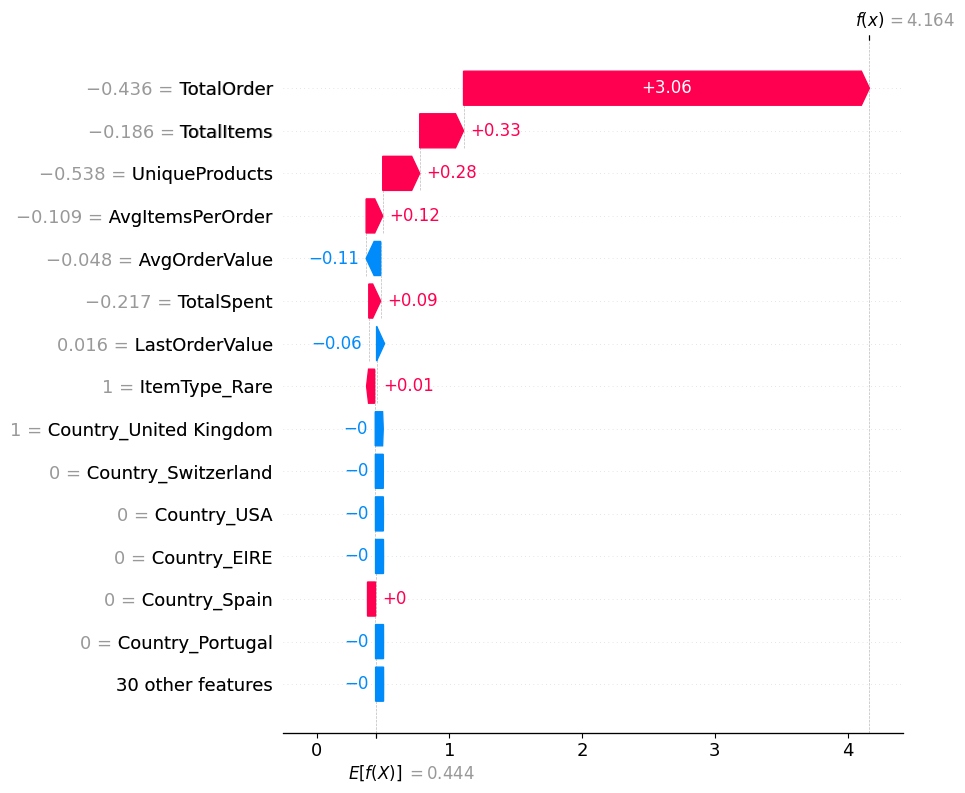

In [73]:
import shap

# Extract pipeline parts
cat_pipeline = voting_model.named_estimators_['cat']
preprocessor = cat_pipeline.named_steps['preprocessing']
cat_model = cat_pipeline.named_steps['model']

# Transform data
X_test_transformed = preprocessor.transform(X_test)

# SHAP explainer
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer(X_test_transformed)

# Feature names cleaning
feature_names = preprocessor.get_feature_names_out()
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

# Set feature names inside shap_values
shap_values.feature_names = clean_feature_names

# WATERFALL PLOT (single prediction)
i = 0

shap.plots.waterfall(
    shap_values[i],
    max_display=15
)

## **Insights:**
Features sorted by importance:

- Red → increase prediction

- Blue → decrease prediction

This waterfall plot shows how individual features contribute to a single prediction.

1. Rare items slightly increases churn probability. But impact is small.
2. The model is primarily driven by customer purchasing behavior rather than demographics.
3. TotalOrder dominates prediction, meaning frequency of transactions is the strongest indicator.
4. Average order value negatively impacts prediction, suggesting frequent smaller purchases matter more than large occasional ones.

Overall, the prediction is mainly influenced by purchasing frequency and volume rather than customer location.

SHAP values are in log-odds space.The prediction is driven overwhelmingly by TotalOrder (~76% contribution), pushing the output from a baseline (~0.5 log-odds) to a very high value (~4.2), meaning this instance’s risk is almost entirely explained by low order frequency, with other features having minimal impact.

## Categorizing customers into High, Medium and Low Churn risk:


In [83]:
import pandas as pd

risk_df = X_test.copy()
risk_df['churn_prob'] = vote_prob

def assign_risk(p):
    if p >= 0.7:
        return "High"
    elif p >= 0.4:
        return "Medium"
    else:
        return "Low"

risk_df['risk_segment'] = risk_df['churn_prob'].apply(assign_risk)


In [84]:
# Calculate % of customers in each segment
risk_distribution = risk_df['risk_segment'].value_counts(normalize=True) * 100
print(risk_distribution)


risk_segment
Low       47.645740
High      28.026906
Medium    24.327354
Name: proportion, dtype: float64


- Customers the model labeled high risk mostly did leave.

- Customers labeled low risk mostly stayed.

- Medium-risk customers behaved somewhere in between.

So the model is correctly ranking customers by their likelihood of leaving.

In [85]:
import joblib
joblib.dump(voting_model, "churn_model.pkl")

['churn_model.pkl']

## Experimentation:

In [86]:
risk_df

,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,LastOrderValue,ItemType,churn_prob,risk_segment
1541,1,349.55,147,7.736842,18.397368,19,United Kingdom,349.55,Rare,0.983874,High
2591,4,1617.63,483,13.800000,46.218000,33,Channel Islands,212.40,Rare,0.351743,Low
5470,7,112.32,70,1.228070,1.970526,42,United Kingdom,6.24,Rare,0.747345,High
742,1,236.11,76,3.800000,11.805500,19,United Kingdom,236.11,Rare,0.991043,High
5540,8,3236.72,1085,3.030726,9.041117,313,United Kingdom,503.35,Rare,0.289686,Low
...,...,...,...,...,...,...,...,...,...,...,...
1600,7,1745.43,2823,49.526316,30.621579,49,United Kingdom,75.60,Rare,0.286218,Low
3901,1,114.56,182,11.375000,7.160000,16,United Kingdom,114.56,Rare,0.972932,High
5052,3,653.38,310,8.157895,17.194211,30,United Kingdom,124.93,Frequent,0.410658,Medium
2501,4,1320.60,529,8.138462,20.316923,56,United Kingdom,309.40,Frequent,0.325812,Low


In [87]:
# treatment column tells us: Which customers received an offer (treatment) and which did not (control)
# Received Offer (treatment = 1)
# Not received offer (treatment = 0)

import numpy as np
np.random.seed(42)
risk_df['treatment'] = np.random.choice([0,1], size=len(risk_df))

# 1 = customer receives retention offer
# 0 = no offer

In [88]:
# Now, we create a new column called simulated_churn that represents:
# "What would happen to customers after we give them an offer"

import numpy as np

# Step 1: Start with original churn (actual labels)
risk_df['simulated_churn'] = y_test.values

# Step 2: Reduce probability by 20% (only for treated customers)
prob_after_offer = risk_df['churn_prob'] * 0.6

# Step 3: Apply simulation ONLY where treatment = 1
mask = (risk_df['treatment'] == 1) & (risk_df['risk_segment'] == 'High')

risk_df.loc[mask, 'simulated_churn'] = np.random.binomial(
    1,
    prob_after_offer[mask]
)
# For customers who received the offer (treatment = 1):
# If they were going to churn (1), now they become 0.8
# If they were not going to churn (0), they remain 0

# Note: multiplying by 0.8 mean?
# “The offer reduces churn probability by 20%”

In [89]:
risk_df.sample(15)

,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,LastOrderValue,ItemType,churn_prob,risk_segment,treatment,simulated_churn
3576,2,727.20,272,11.333333,30.300000,11,United Kingdom,-11.80,Rare,0.709854,High,0,1
4095,6,1023.48,483,5.551724,11.764138,68,United Kingdom,170.20,Rare,0.409353,Medium,0,0
1108,1,219.87,198,8.608696,9.559565,23,United Kingdom,219.87,Frequent,0.977540,High,0,1
968,5,584.16,486,6.311688,7.586494,57,United Kingdom,186.47,Frequent,0.426553,Medium,0,0
5415,3,712.78,-2446,-116.476190,33.941905,21,United Kingdom,0.00,Rare,0.571293,Medium,0,1
5781,4,561.53,252,3.652174,8.138116,56,United Kingdom,23.79,Rare,0.622743,Medium,1,0
58,1,63.24,1,1.000000,63.240000,1,Finland,63.24,Frequent,0.982746,High,1,1
3502,1,139.94,46,1.314286,3.998286,34,United Kingdom,139.94,Rare,0.992308,High,1,1
353,1,638.11,373,9.097561,15.563659,41,Germany,638.11,Frequent,0.925551,High,1,1
109,10,5879.95,3302,14.546256,25.902863,199,Cyprus,290.50,Rare,0.129071,Low,0,0


In [90]:
risk_df.groupby('treatment')['churn_prob'].mean()
# Both groups had the SAME risk before intervention

,churn_prob
treatment,
0,0.513786
1,0.513008


In [91]:
risk_df.groupby('treatment')['simulated_churn'].mean()
# It calculates Average churn rate for each group.

,simulated_churn
treatment,
0,0.510251
1,0.399558


- Customers who did NOT receive the offer have 51.02% churn rate.

- Customers who received the offer have 39.95% churn rate.

The retention campaign reduced churn by ~11.07% .


**Relative Improvement:**
(0.5102 - 0.3995) / 0.5102 ≈ ```21.6%``` improvement

In [92]:
treated = risk_df['treatment'] == 1
total_treated = treated.sum()
print(total_treated)

453


In [93]:
# Before (original churn in treated group)
before = y_test[treated].sum()

# After (simulated churn in treated group)
after = risk_df.loc[treated, 'simulated_churn'].sum()

print("Churn Before:", before)
print("Churn After:", after)
print("Customers Saved:", before - after)

Churn Before: 240
Churn After: 181
Customers Saved: 59


In [94]:
# Performing same thing as above but storing in dataframe and variables.
risk_df = risk_df.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Add actual target
risk_df['actual_churn'] = y_test

treated = risk_df[risk_df['treatment']==1]
control = risk_df[risk_df['treatment']==0]

treated_churn = treated['simulated_churn'].mean()
control_churn = control['simulated_churn'].mean()

print("Treated churn:", treated_churn)
print("Control churn:", control_churn)

Treated churn: 0.3995584988962472
Control churn: 0.510250569476082


In [95]:
from scipy.stats import ttest_ind

ttest_ind(treated['simulated_churn'], control['simulated_churn'])

TtestResult(statistic=np.float64(-3.3365701106673726), pvalue=np.float64(0.0008833200005504833), df=np.float64(890.0))

Assumed Hypothesis:

- H₀ (Null Hypothesis): Offer does NOT reduce churn

- H₁ (Alternative Hypothesis): Offer reduces churn

Since, p-value < 0.05 , We Reject Null Hypothesis. This concludes that the retention offer significantly reduces churn in our case and the reduction in churn is very unlikely due to random chance.


---


- Negative sign in ttest value means:

Treatment group churn(39.9%) < Control group churn(51.0%)

👉 Magnitude (3.336) → strong separation between groups

## Uplift modelling:
tells which customers to target with offer.

🎯 **Goal:**

Find customers who are:

Persuadable → will stay only if we give offer

In [96]:
X_cols = X_test.columns   # feature columns


In [97]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

model_treated = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier()),
        ('xgb', XGBClassifier()),
        ('cat', CatBoostClassifier(verbose=0))
    ],
    voting='soft'
)

model_control = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier()),
        ('xgb', XGBClassifier()),
        ('cat', CatBoostClassifier(verbose=0))
    ],
    voting='soft'
)

preprocessor = cat_pipeline.named_steps['preprocessing']

X_treated = preprocessor.transform(treated[X_cols])
X_control = preprocessor.transform(control[X_cols])

# train models
model_treated.fit(X_treated, treated['actual_churn'])
model_control.fit(X_control, control['actual_churn'])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


VotingClassifier(estimators=[('rf', RandomForestClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importan...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('cat', CatBoostClassifier(verbose=0))],
                 voting='soft')

Since, uplift modeling answers:

“How much does the offer change the behavior of each customer?”

- We need to calculate:
Predicted churn WITHOUT offer - Predicted churn WITH offer

In [98]:
# Apply same preprocessor before prediction
X_all = preprocessor.transform(risk_df[X_cols])

p_treated = model_treated.predict_proba(X_all)[:, 1]
p_control = model_control.predict_proba(X_all)[:, 1]

risk_df['uplift_score'] = p_control - p_treated

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


- control = probability of churn without offer

- treated = probability of churn with offer

  So, difference = reduction in churn due to offer

Convert uplift score into customer types so business knows who to target and who to avoid.

In [99]:
risk_df['uplift_segment'] = pd.qcut(
    risk_df['uplift_score'],
    q=3,
    labels=['Do Not Disturb', 'Neutral', 'Persuadable']
)
risk_df

,TotalOrder,TotalSpent,TotalItems,AvgItemsPerOrder,AvgOrderValue,UniqueProducts,Country,LastOrderValue,ItemType,churn_prob,risk_segment,treatment,simulated_churn,actual_churn,uplift_score,uplift_segment
0,1,349.55,147,7.736842,18.397368,19,United Kingdom,349.55,Rare,0.983874,High,0,1,1,0.003167,Neutral
1,4,1617.63,483,13.800000,46.218000,33,Channel Islands,212.40,Rare,0.351743,Low,1,1,1,-0.199717,Do Not Disturb
2,7,112.32,70,1.228070,1.970526,42,United Kingdom,6.24,Rare,0.747345,High,0,0,0,-0.612040,Do Not Disturb
3,1,236.11,76,3.800000,11.805500,19,United Kingdom,236.11,Rare,0.991043,High,0,1,1,-0.002133,Neutral
4,8,3236.72,1085,3.030726,9.041117,313,United Kingdom,503.35,Rare,0.289686,Low,0,0,0,-0.278631,Do Not Disturb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,7,1745.43,2823,49.526316,30.621579,49,United Kingdom,75.60,Rare,0.286218,Low,1,0,0,0.003946,Neutral
888,1,114.56,182,11.375000,7.160000,16,United Kingdom,114.56,Rare,0.972932,High,1,0,1,-0.004247,Neutral
889,3,653.38,310,8.157895,17.194211,30,United Kingdom,124.93,Frequent,0.410658,Medium,0,0,0,-0.289567,Do Not Disturb
890,4,1320.60,529,8.138462,20.316923,56,United Kingdom,309.40,Frequent,0.325812,Low,0,0,0,-0.239453,Do Not Disturb


In [100]:
risk_df.groupby('uplift_segment')['uplift_score'].mean()

/tmp/ipykernel_619/2027250934.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby('uplift_segment')['uplift_score'].mean()


,uplift_score
uplift_segment,
Do Not Disturb,-0.338217
Neutral,-0.002797
Persuadable,0.268757


**1. Persuadable (+0.267):**

Offer reduces churn by ~26.7%. VERY strong positive impact

✅ Target these customers FIRST

**2. Neutral (~0):**

Offer has almost no effect

⚠️ Optional targeting (depends on cost)

**3. Do Not Disturb (-0.338):**

Offer actually increases churn (~33.8%)

🚨 Do NOT target these customers

### **Qini Curve** tells:
 If I target customers based on uplift score, how much better am I than randomly giving offers?

In [101]:
# Sort customers by uplift
qini_df = risk_df.sort_values(by='uplift_score', ascending=False).reset_index(drop=True)

import numpy as np

# Create cumulative groups
qini_df['cum_treated'] = (qini_df['treatment'] == 1).cumsum()
qini_df['cum_control'] = (qini_df['treatment'] == 0).cumsum()

# Count how many treated customers churned so far
qini_df['cum_treated_churn'] = ((qini_df['treatment'] == 1) & (qini_df['simulated_churn'] == 1)).cumsum()
# Count how many control customers churned so far
qini_df['cum_control_churn'] = ((qini_df['treatment'] == 0) & (qini_df['simulated_churn'] == 1)).cumsum()

In [102]:
qini_df['qini'] = qini_df['cum_control_churn'] - qini_df['cum_treated_churn']

In [103]:
qini_df['population'] = np.arange(1, len(qini_df)+1) / len(qini_df)

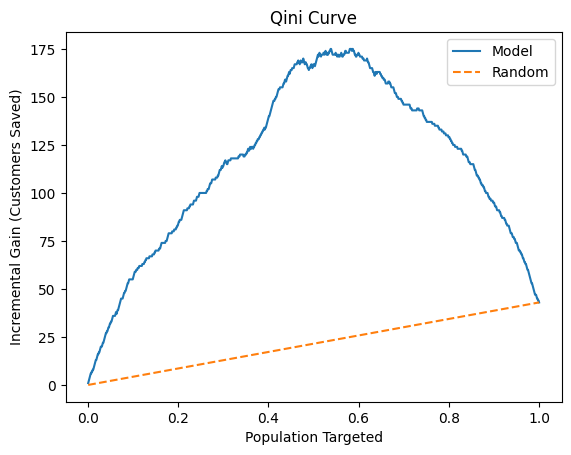

In [104]:
import matplotlib.pyplot as plt

plt.figure()

# Model curve
plt.plot(qini_df['population'], qini_df['qini'], label="Model")

# Random baseline (diagonal)
plt.plot(qini_df['population'],
         qini_df['population'] * qini_df['qini'].iloc[-1],
         linestyle='--',
         label="Random")

plt.xlabel("Population Targeted")
plt.ylabel("Incremental Gain (Customers Saved)")
plt.title("Qini Curve")
plt.legend()

plt.show()

**Key points:**

- This graph shows: How much churn you can reduce by targeting customers using your uplift model instead of targeting randomly

- X-axis tells "What % of customers we are targeting"

- Y-axis tells "How many customers you are saving (reducing churn)"

   -> Higher value = more customers saved

   -> Lower value = less benefit

- Model performs better than random(the orange line).

- Top customers give highest impact (steep rise initially)

- Performance drops after ~50–60% targeting

- Targeting all customers → no extra benefit

- Optimal targeting = top ~50% customers

- Model helps maximize retention & ROI

### **ROI (Return on Investment):**

ROI = (Benefit from customers saved – Cost of offers) / Cost

ROI=
   (Customers Saved × Customer Value) − (Customers Targeted × Offer Cost)
   / Customers Targeted × Offer Cost
	​


In [105]:
offer_cost = 5
customer_value = 100

# Sort customers by uplift
roi_df = risk_df.sort_values(by='uplift_score', ascending=False).reset_index(drop=True)

# Target top 40%
target_size = int(0.4 * len(roi_df))
target_df = roi_df.iloc[:target_size]

# Keep only positive uplift customers
target_df = target_df[target_df['uplift_score'] > 0]

# Expected customers saved
total_saved_customers = target_df['uplift_score'].sum()

# Total benefit
total_benefit = total_saved_customers * customer_value

# Total cost
total_cost = len(target_df) * offer_cost

# ROI
roi = (total_benefit - total_cost) / total_cost

# 🔥 PRINT RESULTS
print("===== ROI ANALYSIS =====")
print(f"Total Customers: {len(risk_df)}")
print(f"Customers Targeted: {len(target_df)}")
print(f"Expected Customers Saved: {total_saved_customers:.2f}")
print(f"Total Benefit (₹): {total_benefit:.2f}")
print(f"Total Cost (₹): {total_cost}")
print(f"Net Profit (₹): {(total_benefit - total_cost):.2f}")
print(f"ROI: {roi:.2f}")

===== ROI ANALYSIS =====
Total Customers: 892
Customers Targeted: 356
Expected Customers Saved: 81.70
Total Benefit (₹): 8170.25
Total Cost (₹): 1780
Net Profit (₹): 6390.25
ROI: 3.59


The campaign targets 356 customers and is expected to retain around 81 of them. With a total cost of ₹1,780, the net profit is ₹6,390, resulting in an ROI of 3.59. This means the strategy generates ₹3.59 return for every ₹1 invested, indicating a highly effective targeting approach.

For every ₹1 you spend, you earn ₹3.59 profit.

# 🏁 Final Conclusion & Business Impact

In this project, we developed a complete **customer churn prediction and retention** using machine learning, explainability, experimentation, and uplift modeling.

### 🎯 Key Achievements

✔ Built a churn prediction model with strong performance  
- ROC-AUC Score: **0.837+**
- F1 Score: **~0.75**
- High recall for churners ensured most at-risk customers were identified

✔ Used SHAP explainability to identify key churn drivers:
- TotalOrder
: More order pattern strongly linked with churn behavior
- TotalItems
: Higher item count increases churn likelihood
- LastOrderValue
: Recent higher purchase → engaged customer

✔ Created churn risk segmentation of customers:
- High Risk
- Medium Risk
- Low Risk

✔ Performed A/B testing simulation:
- Demonstrated statistically significant reduction in churn due to retention offer

✔ Built Uplift Model:
- Identified **Persuadable customers** who respond positively to offers
- Identified **Do Not Disturb customers** where offers may harm

✔ Constructed Qini Curve:
- Showed model significantly outperforms random targeting
- Maximum benefit achieved in **top 50–60% customers**

✔ ROI Analysis:
- Customers Targeted: **356**
- Expected Customers Saved: **82+**
- Campaign Cost: **₹1780**
- Benefit Generated: **₹8170.25**
- Net Profit : **₹6390.25**
- ROI: **3.59x return**

---
